# 09 — Análisis de Outliers entrenando en Mes1

**Objetivo:** Los usuarios `user6` y `user12` mostraron una caída drástica entre Mes0 y los meses posteriores en el análisis principal. Este notebook entrena modelos para ellos utilizando únicamente **Mes1** como set de entrenamiento, y evalúa su rendimiento en los meses posteriores (y anteriores).

- **2 usuarios (user6, user12) × 3 modelos = 6 modelos** entrenados.
- Hiperparámetros fijos.
- Accuracy de Mes1 reportado mediante validación cruzada estratificada (5 folds).

## 0. Configuración del entorno

In [1]:
# ─── Montaje de Drive y configuración de rutas (Colab) ───
import os, sys

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    import glob, os
    paths = glob.glob('/content/drive/**/emg-classification-knn-svm-ann', recursive=True)
    pc = [p for p in paths if 'Othercomputers' in p or 'Ordenadores' in p]
    PROJECT_PATH = max(pc or paths, key=os.path.getmtime) if paths else '/content/drive/Othercomputers/My PC/emg-classification-knn-svm-ann'
    os.chdir(PROJECT_PATH)
    sys.path.insert(0, PROJECT_PATH)
except:
    if 'notebooks' in os.getcwd(): os.chdir('..')
    sys.path.insert(0, os.getcwd())

print('CWD:', os.getcwd())

Mounted at /content/drive
CWD: /content/drive/Othercomputers/My PC (1)/emg-classification-knn-svm-ann


## 1. Imports

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from src.mat_loader import load_all_sessions
from src.intrapersonal import (
    build_features_by_user_month,
    train_user_models,
    evaluate_user_model,
    cross_validate_user_mes0,
    save_user_models,
    CLASS_NAMES,
    DEFAULT_ANN_PARAMS,
)
from src.visualization import get_user_color_map, plot_intrapersonal_accuracy

print('✅ Imports completados')

✅ Imports completados


## 2. Carga de datos longitudinales

In [3]:
BASE_DIR = Path('data/longitudinal/usuarios')

sessions = load_all_sessions(BASE_DIR)
MESES = sorted(sessions.keys(), key=lambda m: int(m.replace('Mes', '')))
print(f'\n📅 Meses detectados: {MESES}')
print(f'   Total de meses: {len(MESES)}')


📅 Cargando Mes0...
  Cargado user12: 300 repeticiones, 988 muestras × 8 canales
  Cargado user14: 300 repeticiones, 988 muestras × 8 canales
  Cargado user21: 300 repeticiones, 988 muestras × 8 canales
  Cargado user23: 300 repeticiones, 988 muestras × 8 canales
  Cargado user24: 300 repeticiones, 990 muestras × 8 canales
  Cargado user26: 300 repeticiones, 988 muestras × 8 canales
  Cargado user35: 300 repeticiones, 988 muestras × 8 canales
  Cargado user37: 300 repeticiones, 988 muestras × 8 canales
  Cargado user4: 300 repeticiones, 988 muestras × 8 canales
  Cargado user40: 300 repeticiones, 988 muestras × 8 canales
  Cargado user42: 300 repeticiones, 988 muestras × 8 canales
  Cargado user43: 300 repeticiones, 988 muestras × 8 canales
  Cargado user49: 300 repeticiones, 988 muestras × 8 canales
  Cargado user5: 300 repeticiones, 984 muestras × 8 canales
  Cargado user55: 300 repeticiones, 988 muestras × 8 canales
  Cargado user57: 300 repeticiones, 988 muestras × 8 canales
  Carg

## 3. Extracción de features por usuario y mes

In [4]:
print('Extrayendo features por usuario y mes...')
features_by_user_month = build_features_by_user_month(sessions)

# Filtramos solo a los outliers
USER_IDS = ['user6', 'user12']

print(f'\n✅ Features extraídas para análisis de outliers: {USER_IDS}')

print(f'\nMuestras en Mes1 (Entrenamiento) por usuario:')
for uid in USER_IDS:
    X, y = features_by_user_month[uid]['Mes1']
    print(f'  {uid}: {X.shape[0]} repeticiones, {X.shape[1]} features')

Extrayendo features por usuario y mes...

✅ Features extraídas para análisis de outliers: ['user6', 'user12']

Muestras en Mes1 (Entrenamiento) por usuario:
  user6: 300 repeticiones, 72 features
  user12: 300 repeticiones, 72 features


## 4. Configuración

In [5]:
user_colors = get_user_color_map(USER_IDS)
ann_params = DEFAULT_ANN_PARAMS.copy()
print('Parámetros ANN:', ann_params)

Parámetros ANN: {'epochs': 200, 'batch_size': 32, 'validation_split': 0.15, 'patience_es': 20, 'patience_lr': 7, 'lr_factor': 0.5, 'verbose': 0}


## 5. Entrenamiento (Mes1) y Evaluación

Para cada usuario:
1. Entrenar en Mes1
2. CV en Mes1
3. Evaluar en el resto de meses

In [6]:
MODELS_DIR = Path('data/processed/models/intrapersonal_outliers')
RESULTS_DIR = Path('data/processed/results')
FIGURES_DIR = RESULTS_DIR / 'figures'

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

all_results = []
total_models_saved = 0
MODEL_NAMES = ['kNN', 'SVM', 'ANN']

for i_user, user_id in enumerate(USER_IDS):
    print(f'\n{"═" * 60}')
    print(f'👤 [{i_user+1}/{len(USER_IDS)}] Procesando {user_id}')
    print(f'{"═" * 60}')

    user_data = features_by_user_month[user_id]
    X_train, y_train = user_data['Mes1']

    print(f'  Entrenando en Mes1: {X_train.shape[0]} muestras')
    models = train_user_models(X_train, y_train, CLASS_NAMES, ann_params=ann_params)

    print(f'  Validación cruzada en Mes1...')
    cv_results = cross_validate_user_mes0(
        X_train, y_train, CLASS_NAMES, n_splits=5, ann_params=ann_params
    )

    for model_name in MODEL_NAMES:
        cv_acc = cv_results[model_name]['accuracy'] * 100
        cv_std = cv_results[model_name]['std'] * 100
        all_results.append({
            'user_id': user_id,
            'model': model_name,
            'mes': 'Mes1',
            'mes_num': 1,
            'accuracy': cv_acc,
            'precision': np.nan,
            'recall': np.nan,
            'f1': np.nan,
            'n_samples': X_train.shape[0],
        })
        print(f'    {model_name} CV (Mes1): {cv_acc:.2f}% (±{cv_std:.2f}%)')

    for mes in MESES:
        if mes == 'Mes1': continue
        mes_num = int(mes.replace('Mes', ''))
        X_test, y_test = user_data[mes]

        for model_name in MODEL_NAMES:
            metrics = evaluate_user_model(models[model_name], X_test, y_test, model_name)
            all_results.append({
                'user_id': user_id, 'model': model_name, 'mes': mes, 'mes_num': mes_num,
                'accuracy': metrics['accuracy'] * 100,
                'precision': metrics['precision'] * 100,
                'recall': metrics['recall'] * 100,
                'f1': metrics['f1'] * 100,
                'n_samples': X_test.shape[0],
            })

        accs = {mn: evaluate_user_model(models[mn], X_test, y_test, mn)['accuracy']*100 for mn in MODEL_NAMES}
        print(f'  {mes}: ' + ' | '.join(f'{mn}: {accs[mn]:.1f}%' for mn in MODEL_NAMES))

    save_user_models(models, user_id, MODELS_DIR)
    total_models_saved += 3



════════════════════════════════════════════════════════════
👤 [1/2] Procesando user6
════════════════════════════════════════════════════════════
  Entrenando en Mes1: 300 muestras
  Validación cruzada en Mes1...


    kNN CV (Mes1): 98.67% (±1.94%)
    SVM CV (Mes1): 100.00% (±0.00%)
    ANN CV (Mes1): 100.00% (±0.00%)
  Mes0: kNN: 51.3% | SVM: 43.3% | ANN: 37.7%
  Mes2: kNN: 67.3% | SVM: 73.0% | ANN: 74.7%
  Mes3: kNN: 92.3% | SVM: 83.3% | ANN: 82.0%
  Mes4: kNN: 90.3% | SVM: 84.7% | ANN: 86.3%
  Mes5: kNN: 85.3% | SVM: 86.7% | ANN: 81.0%
  Mes6: kNN: 59.3% | SVM: 58.7% | ANN: 60.3%

════════════════════════════════════════════════════════════
👤 [2/2] Procesando user12
════════════════════════════════════════════════════════════
  Entrenando en Mes1: 300 muestras
  Validación cruzada en Mes1...
    kNN CV (Mes1): 99.00% (±0.82%)
    SVM CV (Mes1): 99.67% (±0.67%)
    ANN CV (Mes1): 99.33% (±0.82%)
  Mes0: kNN: 40.3% | SVM: 54.7% | ANN: 42.3%
  Mes2: kNN: 71.3% | SVM: 70.0% | ANN: 71.0%
  Mes3: kNN: 35.7% | SVM: 41.7% | ANN: 42.7%
  Mes4: kNN: 31.0% | SVM: 34.7% | ANN: 55.7%
  Mes5: kNN: 24.3% | SVM: 34.7% | ANN: 36.3%
  Mes6: kNN: 28.3% | SVM: 24.7% | ANN: 36.0%


## 6. Resultados

In [7]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(['user_id', 'model', 'mes_num']).reset_index(drop=True)
csv_path = RESULTS_DIR / 'outliers_mes1_results.csv'
results_df.to_csv(csv_path, index=False)
print(f'Resultados en: {csv_path}\n')

pivot = results_df.pivot_table(values='accuracy', index='model', columns='mes', aggfunc='mean')
mes_order = [f'Mes{i}' for i in range(len(MESES))]
pivot = pivot[[m for m in mes_order if m in pivot.columns]]
print('Accuracy Promedio (user6 y user12):')
print(pivot.round(2))

Resultados en: data/processed/results/outliers_mes1_results.csv

Accuracy Promedio (user6 y user12):
mes     Mes0   Mes1   Mes2   Mes3   Mes4   Mes5   Mes6
model                                                 
ANN    40.00  99.67  72.83  62.33  71.00  58.67  48.17
SVM    49.00  99.83  71.50  62.50  59.67  60.67  41.67
kNN    45.83  98.83  69.33  64.00  60.67  54.83  43.83


## 7. Gráficas

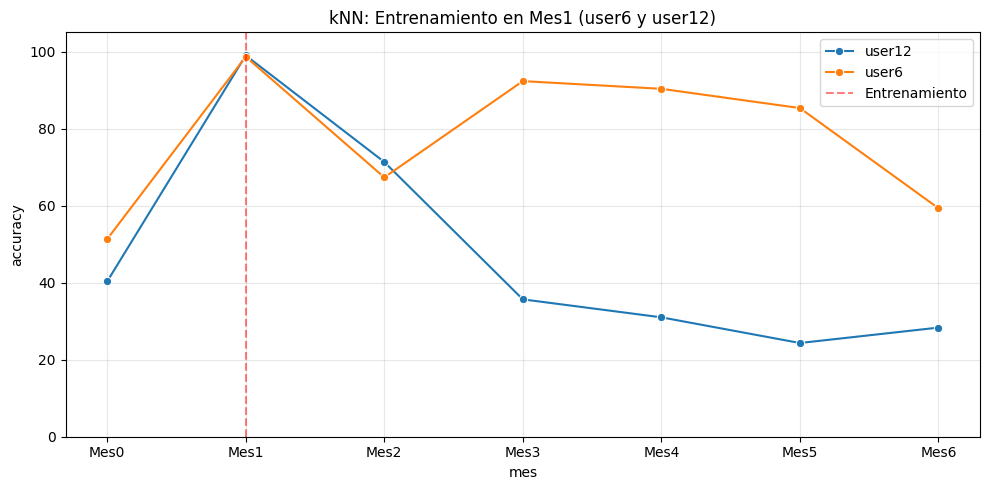

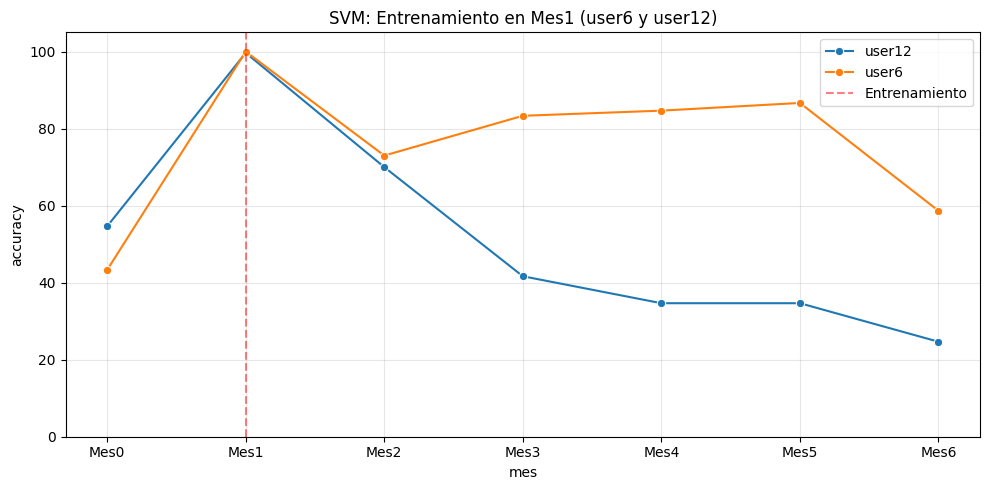

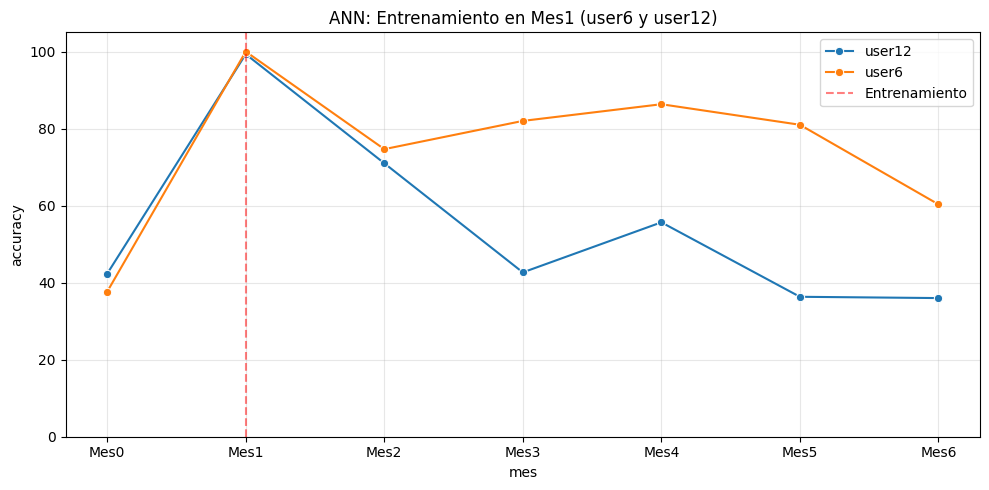

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

for model in MODEL_NAMES:
    sub = results_df[results_df['model'] == model]
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=sub, x='mes', y='accuracy', hue='user_id', marker='o')
    plt.axvline(x='Mes1', color='red', linestyle='--', alpha=0.5, label='Entrenamiento')
    plt.title(f'{model}: Entrenamiento en Mes1 (user6 y user12)')
    plt.ylim(0, 105)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'outliers_mes1_{model.lower()}.png')
    plt.show()